## 1. Setup

In [1]:
# Imports
import os, math
import numpy as np
import polars as pl
import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl
import json
from pathlib import Path
from pytorch_graph import generate_architecture_diagram

/home/epalacios-garcia/Projects/EV-CVAE/.venv/lib/python3.13/site-packages/pytorch_graph/core/parser.py:18: UserWarning: torchinfo not available. Enhanced model summaries will be disabled.
  warnings.warn("torchinfo not available. Enhanced model summaries will be disabled.")


In [2]:
plt.style.use("./pub_pdf.mplstyle")
mm = 1 / 25.4

## 2. Configuration

In [3]:
base_path = Path("../data/")

In [4]:
names_mapping = {
    "PluggedInTime": r'$\Delta t_\mathrm{ses\_h}$',
    "ChargingDuration": r'$\Delta t_\mathrm{cha\_h}$', 
    "ConsumedkWh": r'$E$',
    "TimeGapHours": r'$\Delta t_\mathrm{gap\_h}$', 
    "WeekTime_sin": r'$t_\mathrm{avi\_sin}$', 
    "WeekTime_cos": r'$t_\mathrm{avi\_sin}$', 
    # "PluggedInTime": "PluggedInTime",
    # "ChargingDuration": "ChargingDuration", 
    # "ConsumedkWh": "ConsumedkWh",
    # "TimeGapHours": "TimeGapHours", 
    # "WeekTime_sin": "WeekTime_sin", 
    # "WeekTime_cos": "WeekTime_cos", 
}

In [5]:
# Input file path
INPUT_FILE = base_path / "processed/Transactions_preprocessedV3.4.7_combined.parquet"

# Checkpoint and stats paths
CKPT_PATH   = base_path / "generated/cvae_ev_v348.pt"
STATS_FILE  = base_path / "scaled/scale_stats.json"

# Feature columns
x_cols   = ["PluggedInTime", "ChargingDuration", "ConsumedkWh", "TimeGapHours", "WeekTime_sin", "WeekTime_cos"]
pos_cols = ["PluggedInTime", "ChargingDuration", "ConsumedkWh", "TimeGapHours"]  # features that need log1p

# Model hyperparameters
feature_size = 6
class_size   = 8    # 7 day-of-week one-hot + 1 managed flag
latent_size  = 64
hidden_size  = 256

# Training hyperparameters
EPOCHS      = 60
lr          = 0.0003
weight_decay = 0
grad_clip   = None
beta        = 0.5
z_scale     = 1
T           = 1.0   # sampling temperature

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 3. Load & Inspect Data

In [6]:
df = pl.read_parquet(INPUT_FILE)
feature_names = df.columns
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Loaded: 111,179 rows, 8 columns


PluggedInTime,ChargingDuration,ConsumedkWh,Part_of_Managed_Group,TimeGapHours,DayOfWeek,WeekTime_sin,WeekTime_cos
f64,f64,f64,i8,f64,f64,f64,f64
10.016667,4.683333,31.23,0,0.016667,2.0,0.529919,-0.848048
14.4,3.883333,26.24,0,0.033333,0.0,0.631739,0.775181
23.666667,3.116667,20.92,0,0.016667,4.0,-0.85588,-0.517174
83.766667,4.4,30.59,0,0.016667,3.0,-0.385561,-0.922682
12.2,3.666667,24.88,0,0.016667,3.0,-0.350207,-0.936672


## 4. CVAE Model Definition

In [7]:
import torch.nn.functional as F

# CVAE with Gaussian NLL reconstruction (drop‑in replacement for V3.3 model/loss)
# Notes:
#  - Decoder predicts mean and log-variance per feature.
#  - Gaussian NLL is computed analytically (no sampling from p(x|z,c) during training).
#  - We clamp log-variance for numeric stability to prevent exploding/vanishing variance that can cause "random days" effects.
#  - Condition c is ONE-HOT (e.g., day-of-week size=7) and is concatenated to inputs of both encoder and decoder.
#  - At generation time you can either use the mean (deterministic) or sample using the predicted variance.

class CVAE(nn.Module):
    def __init__(self,
                 latent_size: int,
                 hidden_size: int,
                 feature_size: int = len(feature_names),      # number of *continuous* features you reconstruct (NOT including the condition)
                 class_size: int = 8,        # one-hot day-of-week typically
                 logvar_min: float = -6.0,   # clamp for numerical stability
                 logvar_max: float = 1.5):
        super().__init__()
        self.feature_size = feature_size
        self.class_size = class_size
        self.latent_size = latent_size
        self.logvar_min = logvar_min
        self.logvar_max = logvar_max

        # Encoder q(z|x, c)
        self.enc_fc1 = nn.Linear(feature_size + class_size, hidden_size)
        self.enc_fc2 = nn.Linear(hidden_size, hidden_size)
        self.enc_mu = nn.Linear(hidden_size, latent_size)
        self.enc_logvar = nn.Linear(hidden_size, latent_size)

        # Decoder p(x|z, c) — outputs per-feature mean and log-variance
        self.dec_fc1 = nn.Linear(latent_size + class_size, hidden_size)
        self.dec_fc2 = nn.Linear(hidden_size, hidden_size)
        self.dec_mu = nn.Linear(hidden_size, feature_size)
        self.dec_logvar = nn.Linear(hidden_size, feature_size)

    def encode(self, x: torch.Tensor, c: torch.Tensor):
        h = F.relu(self.enc_fc1(torch.cat([x, c], dim=-1)))
        h = F.relu(self.enc_fc2(h))
        mu = self.enc_mu(h)
        logvar = self.enc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor, T: float = 1.0):
        # Reparameterization trick with optional temperature T for sampling control
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + (std * eps * T)

    def decode(self, z: torch.Tensor, c: torch.Tensor):
        h = F.relu(self.dec_fc1(torch.cat([z, c], dim=-1)))
        h = F.relu(self.dec_fc2(h))
        x_mu = self.dec_mu(h)
        x_logvar = self.dec_logvar(h)
        # clamp for stability; prevents the model from setting huge variance that makes outputs look random
        x_logvar = torch.clamp(x_logvar, min=self.logvar_min, max=self.logvar_max)
        #x_logvar = torch.clamp(x_logvar, min=-6.0, max=3.0)
        return x_mu, x_logvar

    def forward(self, x: torch.Tensor, c: torch.Tensor, T: float = 1.0):
        z_mu, z_logvar = self.encode(x, c)
        z = self.reparameterize(z_mu, z_logvar, T=T)
        x_mu, x_logvar = self.decode(z, c)
        return x_mu, x_logvar, z_mu, z_logvar

    @staticmethod
    def gaussian_nll(x_mu: torch.Tensor, x_logvar: torch.Tensor, x: torch.Tensor, reduce: str = "sum"):
        """
        Gaussian negative log-likelihood per feature: 0.5 * [ (x - mu)^2 * exp(-logvar) + logvar + log(2π) ]

        x, x_mu, x_logvar: [B, F]

        Returns:
            - scalar if reduce in {"sum", "mean"}
            - [B, F] if reduce == "none" (or anything else)
        """

        LOG_2PI = math.log(2.0 * math.pi)

        # [B, F] per-sample, per-feature NLL
        nll = 0.5 * ((x - x_mu) ** 2 * torch.exp(-x_logvar) + x_logvar + LOG_2PI)

        if reduce == "sum":
            return nll.sum()
        elif reduce == "mean":
            return nll.mean()
        else:
            return nll

    @staticmethod
    def kld_standard_normal(z_mu: torch.Tensor, z_logvar: torch.Tensor, reduce: str = "sum"):
        # KL(q(z|x,c) || N(0,I))
        kld = -0.5 * (1 + z_logvar - z_mu.pow(2) - z_logvar.exp())
        if reduce == "sum":
            return kld.sum()
        elif reduce == "mean":
            return kld.mean()
        else:
            return kld

    def cvae_loss(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        beta: float = 0.075,
        reduce: str = "sum",
        T: float = 1.0,
        feature_weights: torch.Tensor | None = None,
    ):
        """
        CVAE loss with optional per-feature weighting.

        feature_weights: shape [F] in the same order as input features x.
        If None, all features are equally weighted.
        """
        x_mu, x_logvar, z_mu, z_logvar = self.forward(x, c, T=T)

        # [B, F] per-sample, per-feature NLL
        nll_bf = self.gaussian_nll(x_mu, x_logvar, x, reduce="none")

        if feature_weights is not None:
            # reshape to [1, F] for broadcasting over batch
            w = feature_weights.view(1, -1)
            nll_bf = nll_bf * w

        # now reduce according to `reduce`
        if reduce == "sum":
            recon = nll_bf.sum()
        elif reduce == "mean":
            recon = nll_bf.mean()
        else:
            recon = nll_bf  # (B, F)

        kld = self.kld_standard_normal(z_mu, z_logvar, reduce=reduce)
        return recon + beta * kld, {"recon": recon.detach(), "kld": kld.detach()}


    def per_feature_nll_over_loader(self, data_loader, device):
        """
        Returns average Gaussian NLL per feature over an entire dataloader.
        Shape: [feature_size]
        """
        self.eval()
        feature_sums = torch.zeros(self.feature_size, device=device)
        n_samples = 0

        with torch.no_grad():
            for xb, yb in data_loader:
                xb, yb = xb.to(device), yb.to(device)
                x_mu, x_logvar, z_mu, z_logvar = self(xb, yb)   # forward
                # [B, F] NLL per sample & feature
                nll_bf = self.gaussian_nll(x_mu, x_logvar, xb, reduce="none")
                feature_sums += nll_bf.sum(dim=0)     # sum over batch, keep features
                n_samples += xb.size(0)

        return (feature_sums / n_samples).cpu()       # [F]


# ------------------------------
# Training loop (sketch) — replace your existing criterion with model.loss
# ------------------------------
# model = CVAE(feature_size=6, latent_size=64, class_size=7, hidden_size=128)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
# for epoch in range(EPOCHS):
#     model.train()
#     total, total_recon, total_kld = 0.0, 0.0, 0.0
#     for x_batch, c_batch in train_loader:  # x_batch: (B,6) ; c_batch: (B,7 one-hot)
#         optimizer.zero_grad()
#         loss, parts = model.loss(x_batch, c_batch, beta=0.075, reduce="sum", T=1.0)
#         loss.backward()
#         optimizer.step()
#         total += loss.item()
#         total_recon += parts["recon"].item()
#         total_kld += parts["kld"].item()
#     print(f"epoch {epoch:03d} | loss={total:.1f} recon={total_recon:.1f} kld={total_kld:.1f}")

# ------------------------------
# Generation examples
# ------------------------------
# with torch.no_grad():
#     B = 16
#     # choose a day index 0..6 and make one-hot condition vector c
#     day_idx = 4  # e.g., Friday
#     c = torch.zeros(B, 7)
#     c[:, day_idx] = 1.0
#     # sample z ~ N(0,I)
#     z = torch.randn(B, model.latent_size)
#     x_mu, x_logvar = model.decode(z, c)
#     # deterministic outputs (useful when variance is still high):
#     x_det = x_mu
#     # stochastic outputs (samples from p(x|z,c)):
#     x_samples = x_mu + torch.exp(0.5 * x_logvar) * torch.randn_like(x_mu)

# ------------------------------
# Practical tips to avoid "random days" effect
# ------------------------------
# 1) Do NOT include the day index among the reconstructed features; only condition on it (c).
# 2) Keep feature scaling consistent (fit on train, apply to val/test/generation) and invert after generation.
# 3) Clamp decoder log-variance as in this code; without a floor/ceiling, the model may inflate variance.
# 4) Start with deterministic generation (use x_mu) to sanity-check conditioning, then enable sampling.
# 5) Monitor per-feature NLL; if a feature's logvar goes to the max clamp, lower logvar_max or increase beta slightly.

## 5. Data Preprocessing

In [8]:
# Build feature matrix X and condition matrix Y from the raw dataframe
X = df.select(x_cols).to_numpy().astype(np.float32)

day     = df["DayOfWeek"].to_numpy().astype(int)
managed = (df["Part_of_Managed_Group"].to_numpy().astype(np.int32) > 0).astype(np.float32).reshape(-1, 1)

# Condition vector: 7-dim day-of-week one-hot + 1 managed flag
Y_day = np.eye(7)[day].astype(np.float32)
Y     = np.concatenate([Y_day, managed], axis=1).astype(np.float32)

# Apply log1p to non-negative features to reduce skew
pos_idx = [x_cols.index(c) for c in pos_cols]
X[:, pos_idx] = np.log1p(np.clip(X[:, pos_idx], 0, None))

# Train / val / test split (70 / 15 / 15)
N   = len(X)
rng = np.random.default_rng(0)
perm = rng.permutation(N)
n_tr = int(0.7 * N)
n_v  = int(0.15 * N)
train_idx = perm[:n_tr]
val_idx   = perm[n_tr:n_tr + n_v]
test_idx  = perm[n_tr + n_v:]

# Z-score scaling fitted on training data only
mu = X[train_idx].mean(axis=0)
sd = X[train_idx].std(axis=0, ddof=0)
sd[sd == 0] = 1.0
X_scaled = (X - mu) / sd

# Save scaling stats for later inverse-transform
stats = {
    "columns": x_cols,
    "stats": {
        c: {"mean": float(mu[j]), "std": float(sd[j]), "log1p": c in pos_cols}
        for j, c in enumerate(x_cols)
    }
}
with open(STATS_FILE, "w") as f:
    json.dump(stats, f, indent=2)

print(f"Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}")
print("Scaling stats saved to:", STATS_FILE)

Train: 77,825 | Val: 16,676 | Test: 16,678
Scaling stats saved to: ../data/scaled/scale_stats.json


In [9]:
# Build PyTorch datasets and dataloaders
class XYDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

train_ds = XYDataset(X_scaled[train_idx], Y[train_idx])
val_ds   = XYDataset(X_scaled[val_idx],   Y[val_idx])
test_ds  = XYDataset(X_scaled[test_idx],  Y[test_idx])

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256)
test_loader  = DataLoader(test_ds,  batch_size=256)

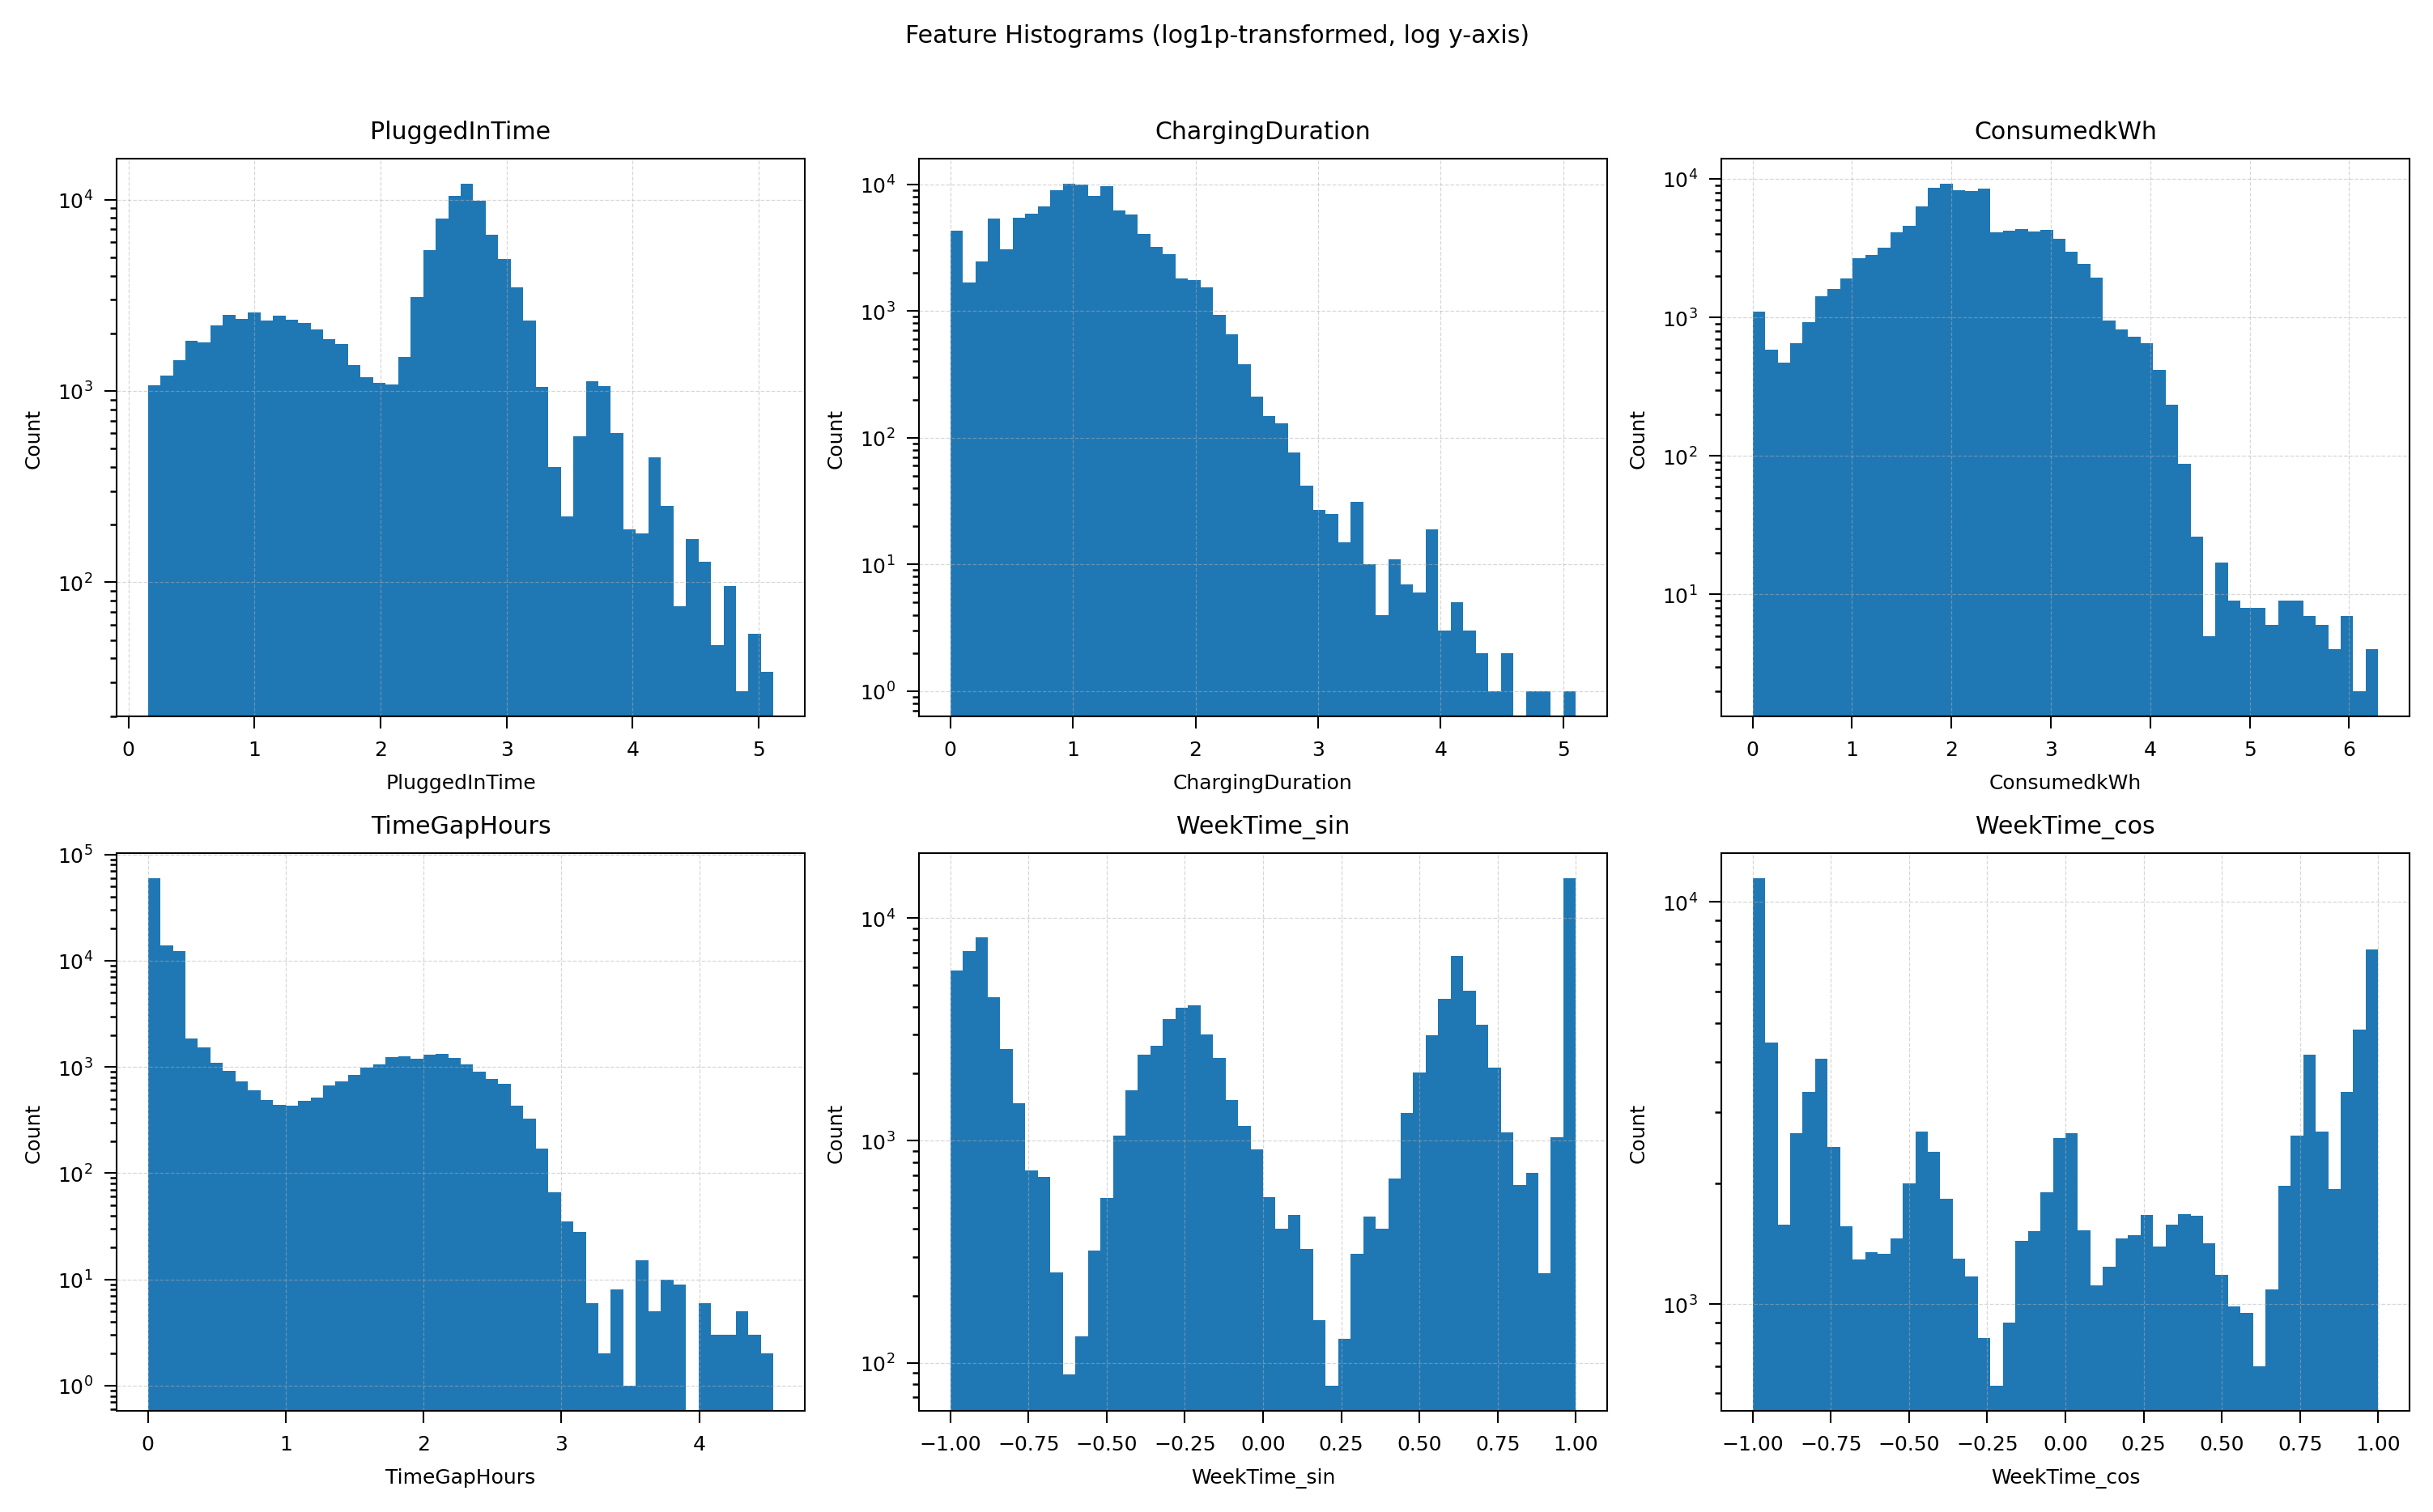

In [10]:
# Feature distribution histograms (log1p-transformed, before z-score scaling)
import pandas as pd

df_all = pd.DataFrame(X, columns=x_cols)

n_cols_plot = 3
n_rows_plot = int(np.ceil(len(x_cols) / n_cols_plot))
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(10, 6))
axes = axes.ravel()

for i, col in enumerate(x_cols):
    axes[i].hist(df_all[col], bins=50, density=False)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].set_yscale("log")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Histograms (log1p-transformed, log y-axis)", y=1.02)
plt.tight_layout()
plt.show()

## 6. Instantiate Model & Optimiser

In [11]:
model = CVAE(
    feature_size=feature_size,
    latent_size=latent_size,
    class_size=class_size,
    hidden_size=hidden_size,
).to(device)

opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

# Per-feature loss weights (same order as x_cols)
# [PluggedInTime, ChargingDuration, ConsumedkWh, TimeGapHours, WeekTime_sin, WeekTime_cos]
raw_weights     = torch.tensor([2, 2.5, 1, 2.5, 0.5, 3.5], device=device, dtype=torch.float32)
feature_weights = raw_weights / raw_weights.mean()   # normalise so mean weight == 1

In [12]:
generate_architecture_diagram(
    model=model,
    input_shape=(1, 784),
    output_path= base_path / "figures/model_architecture.png",
    title="My Neural Network"
)

/home/epalacios-garcia/Projects/EV-CVAE/.venv/lib/python3.13/site-packages/pytorch_graph/core/parser.py:100: UserWarning: Forward pass failed: CVAE.forward() missing 1 required positional argument: 'c'. Using structure-only parsing.
  warnings.warn(f"Forward pass failed: {e}. Using structure-only parsing.")


PosixPath('../data/figures/model_architecture.png')

## 7. Training

In [13]:
train_losses_history = []
val_losses_history = []

train_feature_nll_history = []
val_feature_nll_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    # NEW: accumulators for per-feature NLL
    train_feature_sums   = torch.zeros(feature_size, device=device)
    train_sample_count   = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()

        # use cvae_loss once (no extra forward), with feature weights
        loss, _ = model.cvae_loss(xb, yb, beta=beta, reduce="sum", feature_weights=feature_weights)
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        opt.step()

        train_loss += loss.item()

        # NEW: per-feature NLL for this batch
        with torch.no_grad():
            x_mu, x_logvar, _, _ = model(xb, yb)
            # [B, F] per-sample, per-feature NLL
            nll_bf = model.gaussian_nll(x_mu, x_logvar, xb, reduce="none")
            train_feature_sums += nll_bf.sum(dim=0)   # sum over batch, keep features
            train_sample_count += xb.size(0)

    avg_train_loss = train_loss / len(train_ds)
    train_losses_history.append(avg_train_loss)

    # NEW: average per-feature NLL over the whole training set
    avg_train_feature_nll = (train_feature_sums / train_sample_count).detach().cpu().numpy()
    train_feature_nll_history.append(avg_train_feature_nll)

    #Validation
    model.eval()
    val_loss = 0.0

    # NEW: accumulators for per-feature NLL on validation
    val_feature_sums   = torch.zeros(feature_size, device=device)
    val_sample_count   = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            batch_loss, _ = model.cvae_loss(xb, yb, beta=beta, reduce="sum", feature_weights=feature_weights)
            val_loss += batch_loss.item()

            # NEW: per-feature NLL for this batch
            x_mu, x_logvar, _, _ = model(xb, yb)
            nll_bf = model.gaussian_nll(x_mu, x_logvar, xb, reduce="none")
            val_feature_sums += nll_bf.sum(dim=0)
            val_sample_count += xb.size(0)

    avg_val_loss = val_loss / len(val_ds)
    val_losses_history.append(avg_val_loss)

    # NEW: average per-feature NLL over the whole validation set
    avg_val_feature_nll = (val_feature_sums / val_sample_count).detach().cpu().numpy()
    val_feature_nll_history.append(avg_val_feature_nll)

    print(f"Epoch {epoch:03d} | train: {avg_train_loss:.4f} | val: {avg_val_loss:.4f}")
    print("  Train per-feature NLL:", avg_train_feature_nll)
    print("  Val   per-feature NLL:", avg_val_feature_nll)

avg_train_feature_nll.sum()

Epoch 001 | train: 5.7342 | val: 3.9818
  Train per-feature NLL: [1.2259755  1.03031    1.1610405  0.43612698 1.3340713  0.42767864]
  Val   per-feature NLL: [ 1.1631584   0.80413187  1.0445807  -0.09625082  1.242761   -0.12212413]
Epoch 002 | train: 3.3513 | val: 2.7254
  Train per-feature NLL: [ 1.0947773   0.6253517   0.9892771  -0.32935008  1.0470319  -0.23477508]
  Val   per-feature NLL: [ 0.9535835   0.3695959   0.9432805  -0.43803027  0.7033213  -0.33181396]
Epoch 003 | train: 2.1515 | val: 1.7315
  Train per-feature NLL: [ 0.82227564 -0.0873462   0.8817467  -0.45803022  0.38947773 -0.36953402]
  Val   per-feature NLL: [ 0.7232716  -0.41327998  0.83851516 -0.51173586  0.21740705 -0.40504408]
Epoch 004 | train: 1.1722 | val: 0.6668
  Train per-feature NLL: [ 0.48588088 -0.74244153  0.8070199  -0.5731324   0.09648639 -0.45196143]
  Val   per-feature NLL: [-0.04930803 -0.9384961   0.758795   -0.65290654 -0.00773382 -0.4512328 ]
Epoch 005 | train: 0.1126 | val: -0.3242
  Train per-f

np.float32(-8.0663595)

## 8. Training Diagnostics

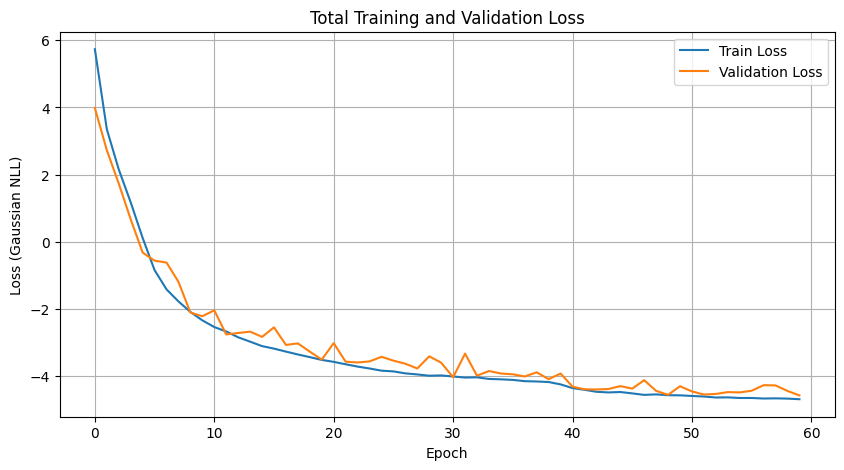

In [14]:
# Total loss curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses_history, label="Train Loss")
plt.plot(val_losses_history,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (Gaussian NLL)")
plt.title("Total Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
colors = plt.cm.tab20.colors

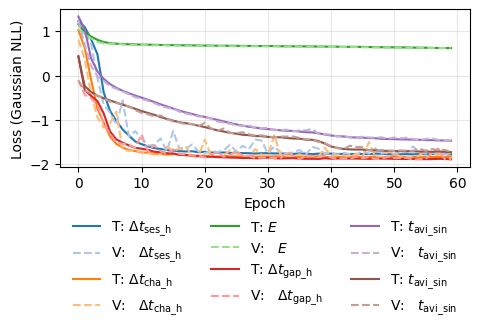

In [16]:
# Per-feature NLL loss curves
fig, ax = plt.subplots(figsize=(120 * mm, 80 * mm), layout="constrained")

train_lines, val_lines = [], []
j=0
for i, fname in enumerate(x_cols):
    train_curve = [e[i] for e in train_feature_nll_history]
    val_curve   = [e[i] for e in val_feature_nll_history]
    tl, = ax.plot(range(EPOCHS), train_curve, linestyle="-",  label=f"Train: {names_mapping[fname]}", color=colors[j])
    j +=1
    vl, = ax.plot(range(EPOCHS), val_curve,   linestyle="--",label=f"Val:   {names_mapping[fname]}", color=colors[j])
    j +=1
    train_lines.append(tl)
    val_lines.append(vl)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (Gaussian NLL)")
ax.grid(True, alpha=0.3)

# Interleaved legend: Train_1, Val_1, Train_2, Val_2, ...
handles = [h for pair in zip(train_lines, val_lines) for h in pair]
labels  = [l for pair in zip([f"T: {names_mapping[n]}" for n in x_cols], [f"V:   {names_mapping[n]}" for n in x_cols]) for l in pair]
ax.legend(handles, labels, ncol=3,
          loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=False)
plt.show()
fig.savefig( base_path / "figures/loss.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight")   


## 9. Latent Space Visualisation

In [17]:
# === Latent space visualisation on the validation set ===

model.eval()

all_mu = []
all_labels = []

with torch.no_grad():
    for xb, yb in val_loader:      # (X_scaled batch, one-hot day-of-week)
        xb = xb.to(device)
        yb = yb.to(device)

        # Get posterior mean and logvar of q(z | x, c)
        mu, logvar = model.encode(xb, yb)

        all_mu.append(mu.cpu())
        # Convert one-hot day-of-week back to integer label 0–6
        labels = yb[:,:7].argmax(dim=1).cpu()
        all_labels.append(labels)

# Stack everything into big arrays
all_mu = torch.cat(all_mu, dim=0).numpy()      # shape: [N_val, latent_size]
all_labels = torch.cat(all_labels, dim=0).numpy()  # shape: [N_val]

latent_size = all_mu.shape[1]
print("Latent size:", latent_size, "  Val samples:", all_mu.shape[0])

Latent size: 64   Val samples: 16676


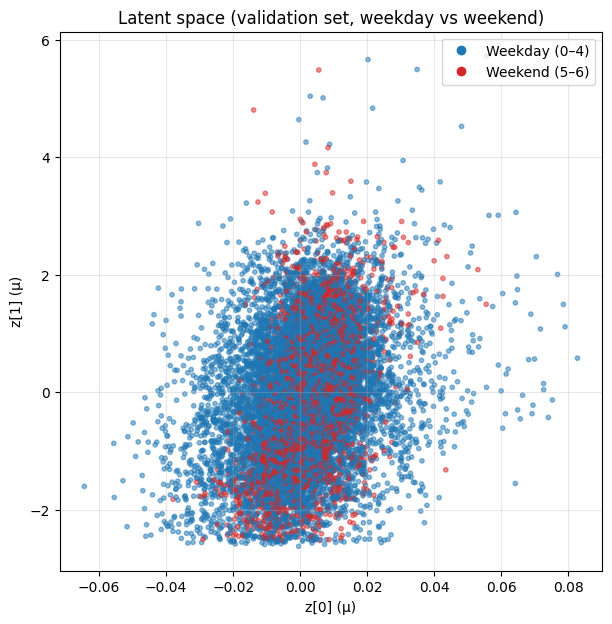

In [18]:
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

z1 = all_mu[:, 0]
z2 = all_mu[:, 1]

# 0–4 = weekday (0), 5–6 = weekend (1)
is_weekend = (all_labels >= 5).astype(int)

# 2-color map: index 0 = weekday, 1 = weekend
cmap_2 = ListedColormap(["C0", "C3"])  # blue, red (or any two Matplotlib default colors)

plt.figure(figsize=(7, 7))
scatter = plt.scatter(
    z1,
    z2,
    c=is_weekend,
    cmap=cmap_2,
    alpha=0.5,
    s=10,
)

plt.xlabel("z[0] (μ)")
plt.ylabel("z[1] (μ)")
plt.title("Latent space (validation set, weekday vs weekend)")

# Custom legend
legend_elements = [
    Line2D([0], [0], marker="o", linestyle="None", color="C0", label="Weekday (0–4)"),
    Line2D([0], [0], marker="o", linestyle="None", color="C3", label="Weekend (5–6)"),
]
plt.legend(handles=legend_elements, loc="upper right")

plt.grid(True, alpha=0.3)
plt.show()

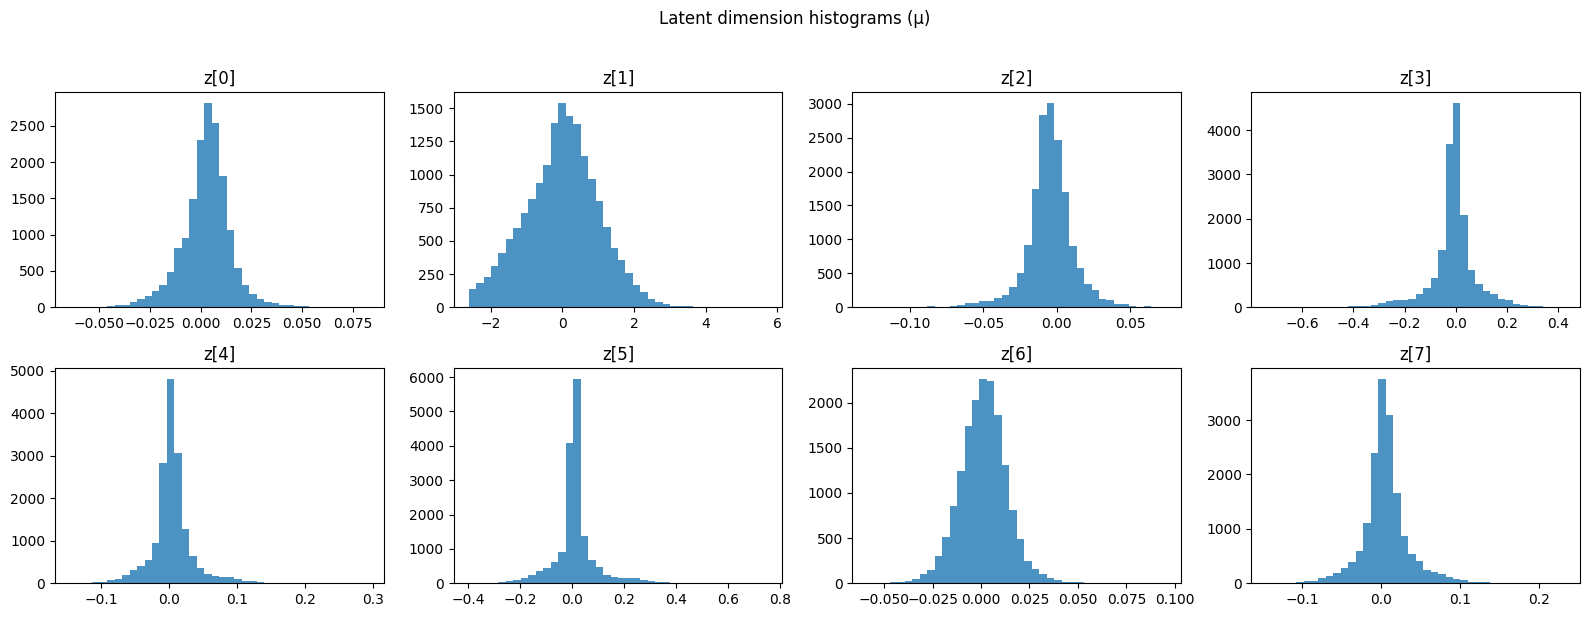

In [19]:
# === Histograms for each latent dimension ===

n_dims_to_show = min(8, latent_size)  # don't spam 64 plots
n_cols = 4
n_rows = math.ceil(n_dims_to_show / n_cols)

plt.figure(figsize=(4 * n_cols, 3 * n_rows))

for i in range(n_dims_to_show):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.hist(all_mu[:, i], bins=40, alpha=0.8)

    # Axis limits as requested
    #plt.xlim(-1, 1)      # x from -6 to 1.2
    #plt.ylim(0, 450)       # y up to 450

    plt.title(f"z[{i}]")

plt.suptitle("Latent dimension histograms (μ)", y=1.02)
plt.tight_layout()
plt.show()

## 10. Save Model Checkpoint

In [20]:
torch.save({
    "model_state":  model.state_dict(),
    "feature_size": feature_size,
    "class_size":   class_size,
    "latent_size":  latent_size,
    "hidden_size":  hidden_size,
    "x_cols":       x_cols,
    "pos_cols":     pos_cols,
    "stats_file":   STATS_FILE,
}, CKPT_PATH)

print("Checkpoint saved:", CKPT_PATH)

Checkpoint saved: ../data/generated/cvae_ev_v348.pt


## 11. Reconstruction Check (Test Batch)

In [21]:
model.eval()
with torch.no_grad():
    xb, yb = next(iter(test_loader))
    xb, yb = xb.to(device), yb.to(device)
    xh, x_logvar, _, _ = model(xb, yb)

xh_np = xh.cpu().numpy()
xb_np = xb.cpu().numpy()

print("Original vs reconstructed (first row):")
print(np.column_stack([xb_np[0], xh_np[0]]))

Original vs reconstructed (first row):
[[ 0.2696737   0.27631006]
 [-1.0668662  -1.1193882 ]
 [-1.1536751  -1.0295097 ]
 [-0.5133425  -0.5293461 ]
 [-0.62664515 -0.8215715 ]
 [-1.2244399  -1.197914  ]]


## 12. Conditional Generation

In [22]:
# Generate samples for a specific day and managed condition
model.eval()
with torch.no_grad():
    N_GEN        = 1000
    day_idx      = 2    # 0=Mon … 6=Sun
    managed_flag = 0    # 0=unmanaged, 1=managed

    y_day = np.eye(7)[[day_idx] * N_GEN].astype(np.float32)
    y_man = np.full((N_GEN, 1), managed_flag, dtype=np.float32)
    y_gen = torch.from_numpy(np.concatenate([y_day, y_man], axis=1)).to(device)

    z      = z_scale * torch.randn(N_GEN, model.latent_size, device=device)
    x_mu, x_logvar = model.decode(z, y_gen)

    x_std    = torch.exp(0.5 * x_logvar)
    x_gen_scaled = (x_mu + T * x_std * torch.randn_like(x_std)).cpu().numpy()

print(f"Generated {N_GEN} samples for day_idx={day_idx}, managed={managed_flag}")
print(x_gen_scaled[:5])

Generated 1000 samples for day_idx=2, managed=0
[[-0.41771835 -0.00890209 -0.12737288 -0.51374555  0.75812095 -1.176312  ]
 [ 0.17965451  0.24862334  0.74069154 -0.42151228  0.7246304  -1.0814397 ]
 [ 1.213712    1.0153357   1.7252527   1.2937807   0.84797406 -1.080699  ]
 [ 0.01568093 -1.3929003  -2.2510552  -0.56244135  0.7007593  -1.1155088 ]
 [ 0.18125078  0.97139186  2.0729551  -0.46335948  0.8128539  -1.0173771 ]]


## 13. Inverse Scaling

In [23]:
# Load scaling stats and invert z-score + log1p transforms
with open(STATS_FILE, "r") as f:
    meta = json.load(f)

cols_order = meta["columns"]
stats      = meta["stats"]

x_unscaled = x_gen_scaled.copy()
for j, col in enumerate(cols_order):
    x_unscaled[:, j] = x_unscaled[:, j] * stats[col]["std"] + stats[col]["mean"]

for j, col in enumerate(cols_order):
    if stats[col].get("log1p", False):
        x_unscaled[:, j] = np.clip(np.expm1(x_unscaled[:, j]), 0, None)

x_gen_unscaled = x_unscaled
print("Inverse-scaling complete.")

# Recover day-of-week and hour-of-day from cyclic encoding
week_angle  = np.arctan2(x_gen_unscaled[:, 4], x_gen_unscaled[:, 5])
week_angle  = np.where(week_angle < 0, week_angle + 2 * np.pi, week_angle)
sec_of_week = week_angle / (2 * np.pi) * 604_800
day_of_week = (sec_of_week // 86_400).astype(int)
hour_of_day = (sec_of_week % 86_400) / 3600

print("Sample day / hour:")
print(np.c_[day_of_week[:5], hour_of_day[:5]])

Inverse-scaling complete.
Sample day / hour:
[[ 2.         20.9919796 ]
 [ 2.         20.56273079]
 [ 2.         18.58797836]
 [ 2.         21.32146263]
 [ 2.         18.38948441]]


## 14. Real vs Generated Comparison

Real samples  (day=2, managed=0): 3139
Generated samples: 1000


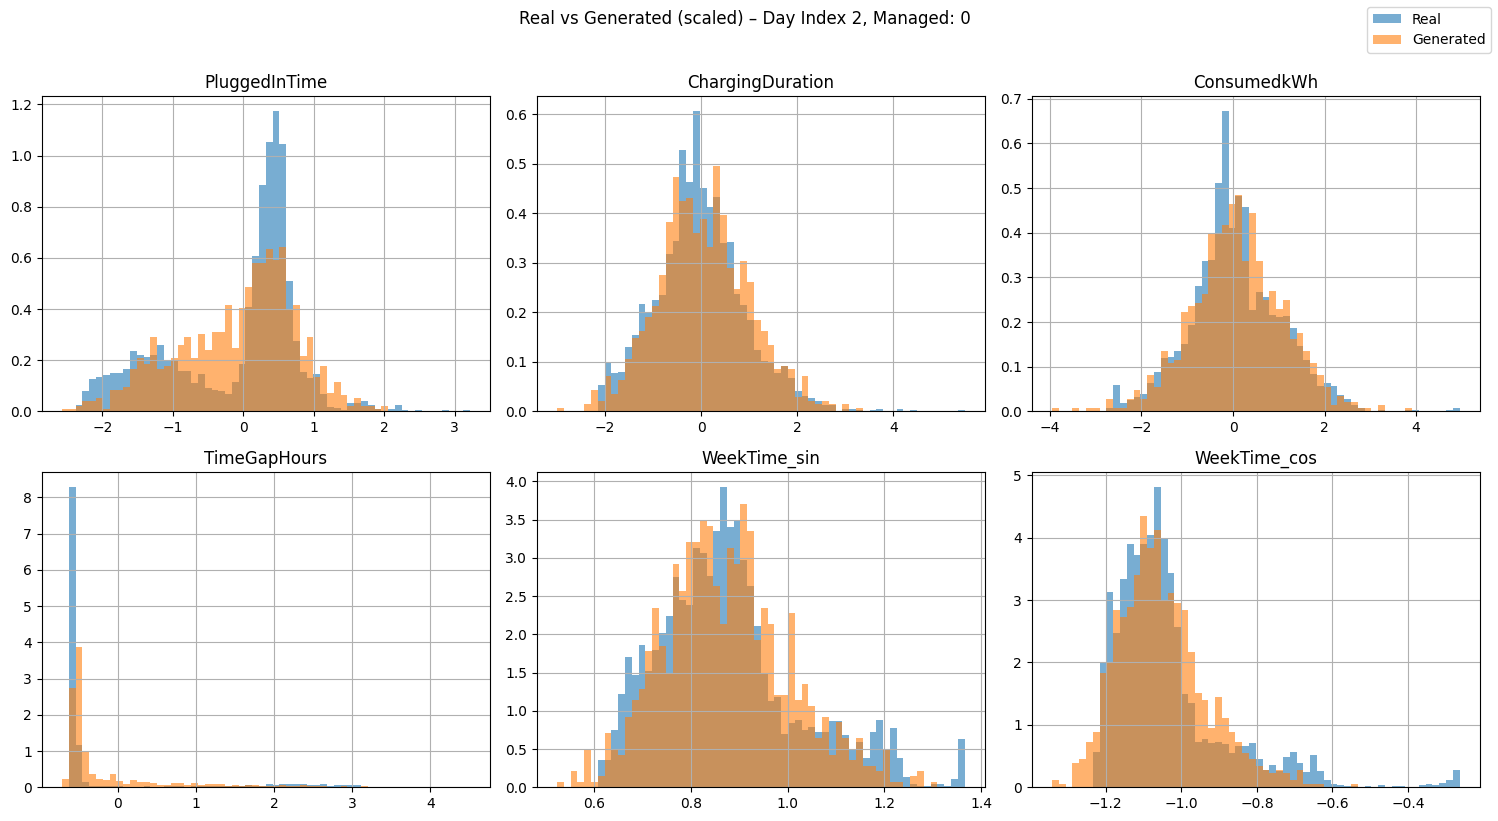


Per-feature mean/std (scaled, day=2, managed=0):
PluggedInTime        real μ= -0.102, σ=  0.921 | gen μ= -0.071, σ=  0.835
ChargingDuration     real μ= -0.028, σ=  0.927 | gen μ=  0.050, σ=  0.948
ConsumedkWh          real μ=  0.048, σ=  0.988 | gen μ=  0.094, σ=  1.002
TimeGapHours         real μ= -0.146, σ=  0.953 | gen μ= -0.140, σ=  0.761
WeekTime_sin         real μ=  0.879, σ=  0.149 | gen μ=  0.873, σ=  0.131
WeekTime_cos         real μ= -1.034, σ=  0.154 | gen μ= -1.051, σ=  0.117


In [24]:
# Compare generated samples against real scaled data for the same condition
target_day_idx = day_idx
target_managed = managed_flag

mask       = (day == target_day_idx) & (managed.squeeze() == target_managed)
X_real_day = X_scaled[mask]
X_gen_day  = x_gen_scaled

print(f"Real samples  (day={target_day_idx}, managed={target_managed}): {X_real_day.shape[0]}")
print(f"Generated samples: {X_gen_day.shape[0]}")

# Histogram comparison
n_feats = len(x_cols)
n_cols_plot = 3
n_rows_plot = math.ceil(n_feats / n_cols_plot)
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(5 * n_cols_plot, 4 * n_rows_plot))
axes = axes.flatten()

for fi, fname in enumerate(x_cols):
    ax = axes[fi]
    real_vals, gen_vals = X_real_day[:, fi], X_gen_day[:, fi]
    vmin = min(real_vals.min(), gen_vals.min())
    vmax = max(real_vals.max(), gen_vals.max())
    ax.hist(real_vals, bins=60, range=(vmin, vmax), alpha=0.6, density=True, label="Real")
    ax.hist(gen_vals,  bins=60, range=(vmin, vmax), alpha=0.6, density=True, label="Generated")
    ax.set_title(fname)
    ax.grid(True)

for ax in axes[n_feats:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle(f"Real vs Generated (scaled) – Day Index {target_day_idx}, Managed: {target_managed}", y=1.02)
plt.tight_layout()
plt.show()

# Per-feature mean/std summary
print(f"\nPer-feature mean/std (scaled, day={target_day_idx}, managed={target_managed}):")
for fi, fname in enumerate(x_cols):
    r, g = X_real_day[:, fi], X_gen_day[:, fi]
    print(f"{fname:20s} real μ={r.mean():7.3f}, σ={r.std(ddof=0):7.3f} | gen μ={g.mean():7.3f}, σ={g.std(ddof=0):7.3f}")

## 15. Real vs Generated Comparison (Unscaled, Test Split)

Real samples for day 2, managed=0: 470
Generated samples for day 2, managed=0: 1000


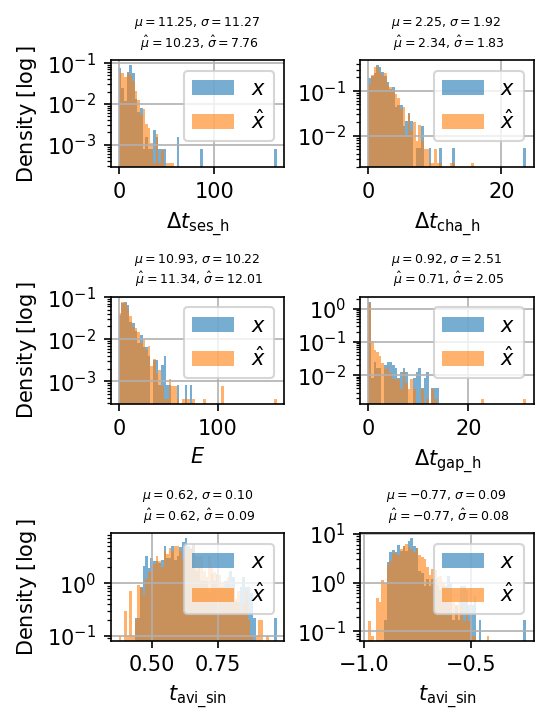


Per-feature mean/std (unscaled, DayIndex = {2} , Managed= {0} :
PluggedInTime        real μ=  11.251, σ=  11.266, min=   0.167, max= 165.283 | gen μ=  10.230, σ=   7.764, min=   0.000, max=  56.770
ChargingDuration     real μ=   2.248, σ=   1.921, min=   0.003, max=  23.700 | gen μ=   2.340, σ=   1.830, min=   0.000, max=  15.426
ConsumedkWh          real μ=  10.935, σ=  10.222, min=   0.100, max=  71.900 | gen μ=  11.344, σ=  12.006, min=   0.000, max= 159.187
TimeGapHours         real μ=   0.916, σ=   2.508, min=   0.000, max=  13.800 | gen μ=   0.709, σ=   2.054, min=   0.000, max=  31.563
WeekTime_sin         real μ=   0.622, σ=   0.100, min=   0.438, max=   0.970 | gen μ=   0.624, σ=   0.093, min=   0.375, max=   0.931
WeekTime_cos         real μ=  -0.771, σ=   0.093, min=  -0.899, max=  -0.244 | gen μ=  -0.775, σ=   0.082, min=  -0.979, max=  -0.423


In [25]:
# Which day to compare (keep this aligned with the generation cell)
target_day_idx = 2  # Saturday

# 1. Select the X_scaled data corresponding to the test_idx
X_test_scaled = X_scaled[test_idx]

# 2. Select the day and managed data corresponding to the test_idx
day_test = day[test_idx]
managed_test = managed[test_idx].squeeze() # Remove extra dimension

# 3. Create a boolean mask by comparing day_test and managed_test with target_day_idx and target_managed
mask_test = (day_test == target_day_idx) & (managed_test == target_managed)

# 4. Apply the mask_test to X_test_scaled to get the real samples for the target day.
X_real_day_scaled = X_test_scaled[mask_test]

# === Inverse-scaling X_real_day_scaled using log1p + z-score stats ===
import json, numpy as np

STATS_FILE = base_path / "scaled" / "scale_stats.json"

# Load preprocessing metadata
with open(STATS_FILE, "r") as f:
    meta = json.load(f)

cols_order = meta["columns"]
stats = meta["stats"]

x_real_unscaled = X_real_day_scaled.copy()
for j, col in enumerate(cols_order):
    mu = stats[col]["mean"]
    sd = stats[col]["std"]
    x_real_unscaled[:, j] = x_real_unscaled[:, j] * sd + mu

for j, col in enumerate(cols_order):
    if stats[col].get("log1p", False):
        x_real_unscaled[:, j] = np.expm1(x_real_unscaled[:, j])
        x_real_unscaled[:, j] = np.clip(x_real_unscaled[:, j], 0, None)

X_real_day = x_real_unscaled


# Generated data: filter by day
X_gen_day  = x_gen_unscaled               # shape: (N_gen, 6) – already Wednesday



print(f"Real samples for day {target_day_idx}, managed={target_managed}: {X_real_day.shape[0]}")
print(f"Generated samples for day {target_day_idx}, managed={target_managed}: {X_gen_day.shape[0]}")

# === Histograms per feature ===
n_feats = len(x_cols)
n_cols = 2
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(90 * mm, 120 * mm), dpi=150, layout="constrained")
axes = axes.flatten()

log_y = True  # toggle this on/off

for fi, fname in enumerate(x_cols):
    ax = axes[fi]

    real_vals = X_real_day[:, fi]
    gen_vals  = X_gen_day[:, fi]
    
    r = X_real_day[:, fi]
    g = X_gen_day[:, fi]

    r_mean, r_std = r.mean(), r.std(ddof=0)
    g_mean, g_std = g.mean(), g.std(ddof=0)

    r_min, r_max = r.min(), r.max()
    g_min, g_max = g.min(), g.max()

    # Common range so shapes are directly comparable
    vmin = min(real_vals.min(), gen_vals.min())
    vmax = max(real_vals.max(), gen_vals.max())

    ax.hist(
        real_vals,
        bins=60, # controls bar width (higher = thinner)
        range=(vmin, vmax),
        alpha=0.6,
        density=True,
        label="${x}$",
    )
    ax.hist(
        gen_vals,
        bins=60,
        range=(vmin, vmax),
        alpha=0.6,
        density=True,
        label="$\\hat{{x}}$",
    )
    ax.legend()

    if log_y:
        ax.set_yscale("log")   # ⬅⬅ key line


    ax.set_xlabel(f"{names_mapping[fname]}")
    if fi%2 != 1:
        ax.set_ylabel(r'Density [$\log$]')
    ax.grid(True)
    ax.set_title(f"$\\mu = {r_mean:.2f}$, $\\sigma ={r_std:.2f}$ \n $\\hat\\mu = {g_mean:.2f}$, $\\hat\\sigma = {g_std:.2f}$", fontsize=6)

# Hide any unused axes
for ax in axes[n_feats:]:
    ax.set_visible(False)

# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right")
# fig.savefig("../data/figures/histogram_gen.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight")   
plt.show()

print("\nPer-feature mean/std (unscaled, DayIndex =", {target_day_idx}, ", Managed=", {target_managed}, ":")
for fi, fname in enumerate(x_cols):
    r = X_real_day[:, fi]
    g = X_gen_day[:, fi]

    r_mean, r_std = r.mean(), r.std(ddof=0)
    g_mean, g_std = g.mean(), g.std(ddof=0)

    r_min, r_max = r.min(), r.max()
    g_min, g_max = g.min(), g.max()

    print(
        f"{fname:20s} "
        f"real μ={r_mean:8.3f}, σ={r_std:8.3f}, min={r_min:8.3f}, max={r_max:8.3f} | "
        f"gen μ={g_mean:8.3f}, σ={g_std:8.3f}, min={g_min:8.3f}, max={g_max:8.3f}"
    )

In [26]:
# Per-feature relative error summary
for fi, fname in enumerate(x_cols):
    r, g = X_real_day[:, fi], X_gen_day[:, fi]
    print(f"{fname:15s} mean_err={abs(g.mean()-r.mean())/abs(r.mean()+1e-8):6.3f}, std_err={abs(g.std()-r.std())/r.std():6.3f}")

PluggedInTime   mean_err= 0.091, std_err= 0.311
ChargingDuration mean_err= 0.041, std_err= 0.047
ConsumedkWh     mean_err= 0.037, std_err= 0.175
TimeGapHours    mean_err= 0.226, std_err= 0.181
WeekTime_sin    mean_err= 0.003, std_err= 0.066
WeekTime_cos    mean_err= 0.005, std_err= 0.118


In [27]:
# Build per-feature stats table and save to Excel
import pandas as pd

rows = []
for fi, fname in enumerate(x_cols):
    r, g = X_real_day[:, fi], X_gen_day[:, fi]
    rows.append({
        "feature":   fname,
        "real_mean": r.mean(), "real_std": r.std(ddof=0), "real_min": r.min(), "real_max": r.max(),
        "gen_mean":  g.mean(), "gen_std":  g.std(ddof=0), "gen_min":  g.min(), "gen_max":  g.max(),
    })

stats_df = pd.DataFrame(rows).rename(columns={"feature": "Feature"}).set_index("Feature")
stats_df.columns = pd.MultiIndex.from_tuples([
    ("Real", "Mean"), ("Real", "Std dev"), ("Real", "Min"), ("Real", "Max"),
    ("Generated", "Mean"), ("Generated", "Std dev"), ("Generated", "Min"), ("Generated", "Max"),
])

display(stats_df)

out_path = base_path / f"generated/per_feature_stats_day_{target_day_idx}.xlsx"
stats_df.to_excel(out_path)
print("Saved stats to:", out_path)

Real                                   Generated  \
                       Mean    Std dev       Min         Max       Mean   
Feature                                                                   
PluggedInTime     11.251277  11.266303  0.166667  165.283340  10.229712   
ChargingDuration   2.248332   1.920875  0.003333   23.700003   2.340072   
ConsumedkWh       10.934597  10.221768  0.100000   71.900009  11.344121   
TimeGapHours       0.915780   2.508027  0.000000   13.800001   0.709133   
WeekTime_sin       0.622198   0.099560  0.438371    0.969842   0.624339   
WeekTime_cos      -0.770876   0.093315 -0.898794   -0.243736  -0.774587   

                                                   
                    Std dev       Min         Max  
Feature                                            
PluggedInTime      7.763800  0.000000   56.770073  
ChargingDuration   1.830312  0.000000   15.425817  
ConsumedkWh       12.005966  0.000000  159.186508  
TimeGapHours       2.054491  0.000000   31.563295  
WeekTime_sin       0.093026  0.374967    0.930933  
WeekTime_cos       0.082303 -0.978775   -0.423333

Saved stats to: ../data/generated/per_feature_stats_day_2.xlsx


## 16. Evaluation Metrics (Wasserstein, Spearman, TSTR)

In [28]:
import numpy as np
import torch

# -------------------------------
# Build a synthetic dataset with the same condition distribution as REAL
# -------------------------------
model.eval()
rng = np.random.default_rng(0)

# Choose which real set to mirror:
# - Use X_scaled / Y for "global"
# - Or use X_scaled[test_idx] / Y[test_idx] if you want to mirror test only
X_real_for_synth = X_scaled
Y_real_for_synth = Y

N_synth = len(X_real_for_synth)  # same size as real (you can reduce if needed)

# Sample condition vectors from real (with replacement) to preserve proportions
idx = rng.integers(0, len(Y_real_for_synth), size=N_synth)
Y_synth_all = Y_real_for_synth[idx].astype(np.float32)  # (N, 8)

# Generate X in batches
batch_size = 4096
Xs = []

with torch.no_grad():
    for start in range(0, N_synth, batch_size):
        end = min(start + batch_size, N_synth)
        yb = torch.from_numpy(Y_synth_all[start:end]).to(device)

        zb = z_scale * torch.randn((end - start, model.latent_size), device=device)
        x_mu, x_logvar = model.decode(zb, yb)

        x_std = torch.exp(0.5 * x_logvar)
        eps = torch.randn_like(x_std)
        x_sample = x_mu + T * x_std * eps  # scaled space

        Xs.append(x_sample.cpu().numpy())

X_synth_all_scaled = np.vstack(Xs).astype(np.float32)

print("X_synth_all_scaled:", X_synth_all_scaled.shape)
print("Y_synth_all:", Y_synth_all.shape)

X_synth_all_scaled: (111179, 6)
Y_synth_all: (111179, 8)


In [29]:
import numpy as np
from scipy.stats import wasserstein_distance, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# Helpers: inverse transform
# -------------------------
def inv_scale(Xs, mu, sd):
    return Xs * sd + mu

def inv_log1p_cols(X, x_cols, pos_cols):
    X = X.copy()
    pos_idx = [x_cols.index(c) for c in pos_cols]
    X[:, pos_idx] = np.expm1(X[:, pos_idx])
    return X

# -------------------------
# 1) Wasserstein metrics
# -------------------------
def w1_per_feature(real, synth):
    return np.array([wasserstein_distance(real[:, d], synth[:, d]) for d in range(real.shape[1])])

def sliced_wasserstein(real, synth, n_proj=200, seed=0):
    rng = np.random.default_rng(seed)
    D = real.shape[1]
    dirs = rng.normal(size=(n_proj, D))
    dirs /= (np.linalg.norm(dirs, axis=1, keepdims=True) + 1e-12)
    vals = []
    for w in dirs:
        vals.append(wasserstein_distance(real @ w, synth @ w))
    return float(np.mean(vals))

# -------------------------
# 2) Spearman corr structure
# -------------------------
def spearman_matrix(x):
    D = x.shape[1]
    R = np.zeros((D, D), dtype=np.float32)
    for i in range(D):
        for j in range(D):
            R[i, j] = spearmanr(x[:, i], x[:, j]).correlation
    return np.nan_to_num(R, nan=0.0)

def corr_mae(real, synth):
    Rr = spearman_matrix(real)
    Rs = spearman_matrix(synth)
    return float(np.mean(np.abs(Rr - Rs)))

# -------------------------
# 3) ACF MAE (build sequences by sorting within each condition)
#    Uses WeekTime_sin/cos to define an ordering in the week.
# -------------------------
def acf_1d(x, max_lag):
    x = np.asarray(x, dtype=np.float64)
    if len(x) < max_lag + 2:
        return None
    x = x - x.mean()
    denom = np.dot(x, x) + 1e-12
    acf = np.empty(max_lag + 1, dtype=np.float64)
    acf[0] = 1.0
    for lag in range(1, max_lag + 1):
        acf[lag] = np.dot(x[:-lag], x[lag:]) / denom
    return acf

def build_sorted_sequence(X_scaled_block, x_cols):
    # sort by week-angle inferred from sin/cos
    si = x_cols.index("WeekTime_sin")
    co = x_cols.index("WeekTime_cos")
    ang = np.arctan2(X_scaled_block[:, si], X_scaled_block[:, co])  # [-pi, pi]
    order = np.argsort(ang)
    return X_scaled_block[order]

def mean_acf_over_blocks(X_scaled, day_arr, managed_arr, x_cols, feature, max_lag=24):
    fi = x_cols.index(feature)
    acfs = []
    for d in range(7):
        for m in [0, 1]:
            mask = (day_arr == d) & (managed_arr == m)
            block = X_scaled[mask]
            if block.shape[0] < max_lag + 2:
                continue
            block = build_sorted_sequence(block, x_cols)
            a = acf_1d(block[:, fi], max_lag=max_lag)
            if a is not None:
                acfs.append(a)
    if not acfs:
        return None
    return np.mean(np.stack(acfs, axis=0), axis=0)

def acf_mae(real_X_scaled, synth_X_scaled, day_real, man_real, x_cols, feature="ConsumedkWh", max_lag=24):
    ar = mean_acf_over_blocks(real_X_scaled, day_real, man_real, x_cols, feature, max_lag=max_lag)
    # For synth we need day/man arrays too (you generated fixed day/man in your cell 17)
    # If you generated fixed day/man, we can fake arrays of same length:
    day_s = np.full((synth_X_scaled.shape[0],), int(target_day_idx), dtype=int)
    man_s = np.full((synth_X_scaled.shape[0],), int(target_managed), dtype=int)

    as_ = mean_acf_over_blocks(synth_X_scaled, day_s, man_s, x_cols, feature, max_lag=max_lag)

    if ar is None or as_ is None:
        return None
    return float(np.mean(np.abs(ar - as_)))

# -------------------------
# 4) TSTR utility (regression)
#    Default: predict ConsumedkWh from the other features + condition
# -------------------------
def tstr_regression(real_X_scaled, real_Y, synth_X_scaled, synth_Y, x_cols, target, seed=0):
    tgt_i = x_cols.index(target)

    # Predict target from remaining features + condition
    Xr = np.concatenate([np.delete(real_X_scaled, tgt_i, axis=1), real_Y], axis=1)
    yr = real_X_scaled[:, tgt_i]  # keep in scaled space for a clean comparison
    Xs = np.concatenate([np.delete(synth_X_scaled, tgt_i, axis=1), synth_Y], axis=1)
    ys = synth_X_scaled[:, tgt_i]

    Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=seed)

    m_syn = RandomForestRegressor(random_state=seed, n_estimators=200, n_jobs=-1)
    m_syn.fit(Xs, ys)
    pred_tstr = m_syn.predict(Xr_te)
    mae_tstr = mean_absolute_error(yr_te, pred_tstr)

    m_real = RandomForestRegressor(random_state=seed, n_estimators=200, n_jobs=-1)
    m_real.fit(Xr_tr, yr_tr)
    pred_rtr = m_real.predict(Xr_te)
    mae_rtr = mean_absolute_error(yr_te, pred_rtr)

    return {"MAE_TSTR_scaled": float(mae_tstr), "MAE_RTR_scaled": float(mae_rtr), "ratio": float(mae_tstr/(mae_rtr+1e-12))}

# =========================================================
# Run evaluation (REAL vs SYNTH) on your chosen subsets
# =========================================================

# 0) Choose the comparison sets you already created
real_scaled = X_real_day          # (N_real, 6)
synth_scaled = X_gen_day          # (N_synth, 6)

# 1) Wasserstein in ORIGINAL units (recommended)
real_orig = inv_log1p_cols(inv_scale(real_scaled, mu, sd), x_cols, pos_cols)
synth_orig = inv_log1p_cols(inv_scale(synth_scaled, mu, sd), x_cols, pos_cols)

w1 = w1_per_feature(real_scaled, synth_scaled) # NEED TO FIX X_REAL_DAY ISSUES
swd = sliced_wasserstein(real_scaled, synth_scaled, n_proj=200, seed=0)

print("\n--- Wasserstein (original units) ---")
for name, val in zip(x_cols, w1):
    print(f"W1 {name:>16s}: {val:.4f}")
print(f"Sliced-W1 (joint, approx): {swd:.4f}")

# 2) Spearman structure (use original units so rank ties are “realistic”)
cmae = corr_mae(real_scaled, synth_scaled)
print("\n--- Dependence structure ---")
print(f"Spearman corr matrix MAE: {cmae:.4f}")

# 3) ACF MAE (uses REAL day/managed arrays from your notebook)
acf_err = acf_mae(X_scaled, synth_scaled, day, managed.squeeze().astype(int),
                  x_cols, feature="ConsumedkWh", max_lag=24)
print("\n--- Temporal-ish structure ---")
print("ACF MAE (ConsumedkWh, lag<=24):", acf_err)

# 4) TSTR (utility) — build synthetic Y to match your generation condition
Y_synth = np.concatenate([np.eye(7)[np.full((synth_scaled.shape[0],), target_day_idx)],
                          np.full((synth_scaled.shape[0], 1), target_managed)], axis=1).astype(np.float32)

tstr = tstr_regression(
    real_X_scaled = X_scaled,
    real_Y        = Y,
    synth_X_scaled= X_synth_all_scaled,
    synth_Y       = Y_synth_all,
    x_cols        = x_cols,
    target        = "ConsumedkWh",
    seed          = 0
)
print("\n--- TSTR utility ---")
print(tstr)

/tmp/ipykernel_200448/2655467317.py:16: RuntimeWarning: overflow encountered in expm1
  X[:, pos_idx] = np.expm1(X[:, pos_idx])



--- Wasserstein (original units) ---
W1    PluggedInTime: 1.8794
W1 ChargingDuration: 0.1659
W1      ConsumedkWh: 0.8053
W1     TimeGapHours: 0.4278
W1     WeekTime_sin: 0.0121
W1     WeekTime_cos: 0.0132
Sliced-W1 (joint, approx): 0.6078

--- Dependence structure ---
Spearman corr matrix MAE: 0.0856

--- Temporal-ish structure ---
ACF MAE (ConsumedkWh, lag<=24): 0.050717492713198496

--- TSTR utility ---
{'MAE_TSTR_scaled': 0.40339801271108944, 'MAE_RTR_scaled': 0.37931974012261993, 'ratio': 1.063477509975153}


In [30]:
# Run TSTR for ConsumedkWh, PluggedInTime, TimeGapHours, ChargingDuration
for target_feature in ["ConsumedkWh", "PluggedInTime", "TimeGapHours", "ChargingDuration"]:
    result = tstr_regression(
        real_X_scaled  = X_scaled,
        real_Y         = Y,
        synth_X_scaled = X_synth_all_scaled,
        synth_Y        = Y_synth_all,
        x_cols         = x_cols,
        target         = target_feature,
        seed           = 0
    )
    print(f"\n--- TSTR: {target_feature} ---")
    print(result)


--- TSTR: ConsumedkWh ---
{'MAE_TSTR_scaled': 0.40339801271108944, 'MAE_RTR_scaled': 0.37931974012261993, 'ratio': 1.063477509975153}

--- TSTR: PluggedInTime ---
{'MAE_TSTR_scaled': 0.5953548265687287, 'MAE_RTR_scaled': 0.5042621543311891, 'ratio': 1.1806454667556334}

--- TSTR: TimeGapHours ---
{'MAE_TSTR_scaled': 0.6409596275988066, 'MAE_RTR_scaled': 0.5917930417459776, 'ratio': 1.0830807096120783}

--- TSTR: ChargingDuration ---
{'MAE_TSTR_scaled': 0.3873634957575761, 'MAE_RTR_scaled': 0.3641780775635173, 'ratio': 1.063665057348081}


In [31]:
# Real
day_real = np.argmax(Y[:, :7], axis=1).astype(int)
man_real = Y[:, 7].round().astype(int)

# Synthetic
day_synth = np.argmax(Y_synth_all[:, :7], axis=1).astype(int)
man_synth = Y_synth_all[:, 7].round().astype(int)

results = []

for d in range(7):
    for m in [0, 1]:

        mask_real  = (day_real == d) & (man_real == m)
        mask_synth = (day_synth == d) & (man_synth == m)

        if mask_real.sum() < 200 or mask_synth.sum() < 200:
            # skip tiny groups to avoid unstable regression
            continue

        out = tstr_regression(
            real_X_scaled = X_scaled[mask_real],
            real_Y        = Y[mask_real],
            synth_X_scaled= X_synth_all_scaled[mask_synth],
            synth_Y       = Y_synth_all[mask_synth],
            x_cols        = x_cols,
            target        = "ConsumedkWh",
            seed          = 4
        )

        results.append({
            "day": d,
            "managed": m,
            "MAE_RTR": out["MAE_RTR_scaled"],
            "MAE_TSTR": out["MAE_TSTR_scaled"],
            "ratio": out["ratio"]
        })

In [32]:
df_tstr = pd.DataFrame(results)
df_tstr = df_tstr.sort_values(["managed", "day"])

day_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
df_tstr["day_name"] = df_tstr["day"].map(day_map)
print(df_tstr[["day_name","managed","ratio"]])

   day_name  managed     ratio
0       Mon        0  1.023676
2       Tue        0  1.054244
4       Wed        0  1.028734
6       Thu        0  1.056827
8       Fri        0  1.021918
10      Sat        0  0.976380
12      Sun        0  1.017366
1       Mon        1  1.089679
3       Tue        1  1.100977
5       Wed        1  1.117905
7       Thu        1  1.100159
9       Fri        1  1.062944
11      Sat        1  1.058937
13      Sun        1  1.041143


## 17. Full Synthetic Dataset Generation (All Days × Managed Flags)

In [33]:
import torch
import pandas as pd
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

N_PER_SCENARIO = 500
LATENT_DIM = 32   # <-- SET THIS TO YOUR LATENT SIZE (Corrected from 8 to 32)

model.eval()

all_rows = []
scenario_id = 0

for day_idx in range(7):              # 0..6
    for managed_flag in [0, 1]:        # 0=unmanaged, 1=managed

        # ---- Build condition exactly like training ----
        # DayOfWeek needs to be one-hot encoded (7 dimensions)
        day_one_hot = torch.nn.functional.one_hot(torch.tensor(day_idx, dtype=torch.long), num_classes=7).to(DEVICE)
        # Managed is a scalar
        managed_tensor = torch.tensor([managed_flag], dtype=torch.float32).to(DEVICE)

        # Concatenate to form the full 8-dimensional condition vector for a single instance
        cond_single_instance = torch.cat([day_one_hot.float(), managed_tensor], dim=-1)

        # Repeat for the batch
        cond_batch = cond_single_instance.unsqueeze(0).repeat(N_PER_SCENARIO, 1)

        # ---- Sample latent ----
        z = torch.randn(N_PER_SCENARIO, LATENT_DIM).to(DEVICE)

        # ---- Decode ----
        with torch.no_grad():
            x_gen_mu, x_gen_logvar = model.decode(z, cond_batch) # Decode returns x_mu, x_logvar
            std = torch.exp(0.5 * x_gen_logvar)
            eps = torch.randn_like(std)
            x_gen = x_gen_mu + T * std * eps

        # For synthetic data generation, often we use the mean or sample from predicted distribution
        # Here, I'll use the mean for simplicity, consistent with some generation examples above
        x_gen = x_gen.detach().cpu().numpy()

        x_unscaled = x_gen.copy()

        for j, col in enumerate(cols_order):
            mu = stats[col]["mean"]
            sd = stats[col]["std"]
            x_unscaled[:, j] = x_unscaled[:, j] * sd + mu

        # Undo log1p transform where required
        for j, col in enumerate(cols_order):
            if stats[col].get("log1p", False):
              x_unscaled[:, j] = np.expm1(x_unscaled[:, j])
              x_unscaled[:, j] = np.clip(x_unscaled[:, j], 0, None)

        # ---- Store rows ----
        for i in range(N_PER_SCENARIO):
            row = {
                "PluggedInTime": float(x_unscaled[i, 0]),
                "ChargingDuration": float(x_unscaled[i, 1]),
                "ConsumedkWh": float(x_unscaled[i, 2]),
                "TimeGapHours": float(x_unscaled[i, 3]),
                "WeekTime_sin": float(x_unscaled[i, 4]),
                "WeekTime_cos": float(x_unscaled[i, 5]),
                "DayOfWeek": day_idx,
                "Managed": managed_flag,
                "ScenarioID": scenario_id
            }
            all_rows.append(row)

        scenario_id += 1

df = pd.DataFrame(all_rows)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (500x40 and 72x256)

In [ ]:
# Save synthetic dataset
out_drive = base_path / "test/synthetic_by_day_managed.parquet"
df.to_parquet(out_drive, index=False)

print("Done.")
print("Total rows:", len(df))

In [ ]:
# Download to local machine
from google.colab import files
files.download("synthetic_by_day_managed.parquet")

## 18. Format & Save Generated Output

In [ ]:
# Build a human-readable DataFrame with reconstructed times
import pandas as pd

def hours_to_hhmm(h):
    if pd.isna(h): return "NaN"
    h  = h % 24
    hh = int(h)
    mm = int(round((h - hh) * 60))
    return f"{hh:02d}:{mm:02d}"

weekday_names = np.array(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

gen_df = pl.DataFrame(x_gen_unscaled, schema=x_cols).select([pl.all().round(7)])

output_df = pd.DataFrame(x_gen_unscaled, columns=x_cols).round(3)
output_df["DayIndex"]  = day_of_week.astype(int)
output_df["HourOfDay"] = hour_of_day
output_df["Day"]       = weekday_names[output_df["DayIndex"] % 7]

output_df["Plug-in_Time"] = np.vectorize(hours_to_hhmm)(output_df["HourOfDay"])
output_df["PlugOutHr"]   = (output_df["HourOfDay"] + output_df["PluggedInTime"]) % 24
output_df["PlugOut"]     = np.vectorize(hours_to_hhmm)(output_df["PlugOutHr"])

output_df["ChargingStartHr"] = (output_df["HourOfDay"] + output_df["TimeGapHours"]) % 24
output_df["ChargingStart"]   = np.vectorize(hours_to_hhmm)(output_df["ChargingStartHr"])

output_df["ChargingEndHr"] = (output_df["ChargingStartHr"] + output_df["ChargingDuration"]) % 24
output_df["ChargingEnd"]   = np.vectorize(hours_to_hhmm)(output_df["ChargingEndHr"])

output_df = output_df.drop(columns=["WeekTime_sin", "WeekTime_cos", "PlugOutHr", "ChargingStartHr", "ChargingEndHr"])
output_df = output_df[["DayIndex", "Day", "Plug-in_Time", "PluggedInTime", "PlugOut",
                        "ChargingStart", "ChargingDuration", "ChargingEnd",
                        "ConsumedkWh", "TimeGapHours"]]

OUTPUT         = base_path / "generated/V3.4.6_Output.csv"
OUTPUT_Parquet = base_path / "generated/V3.4.67_Output.parquet"

gen_df.write_parquet(base_path / "generated/V3.4.6_generated.parquet")
output_df.to_csv(OUTPUT, index=False)
output_df.to_parquet(OUTPUT_Parquet, index=False)

print("Outputs saved.")
output_df.head(10)